# Introduction

We will use the Gemma 4:E2B model fine-tuned using Unsloth for a sentiment analysis task.

The notebook [Fine-tune Gemma 4:E2B with Unsloth](https://www.kaggle.com/code/gpreda/fine-tune-gemma-4-e2b-with-unsloth) was used to evaluate the initial model and fine-tune it with the dataset from Financial Sentiment Analysis.

Let's prepare for loading the fine-tuned model.

In [1]:
!pip install -U -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset, Dataset
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load the model and LoRA weights

In [4]:
from unsloth import FastLanguageModel

checkpoint_path = "/kaggle/input/notebooks/gpreda/fine-tune-gemma-4-e2b-with-unsloth/outputs_gemma4_E2B/checkpoint-1125"
max_seq_length = 512

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=checkpoint_path,   # point directly to the adapter checkpoint folder
    max_seq_length=max_seq_length,
    load_in_4bit=False,
    load_in_16bit=True,
    full_finetuning=False,
)

FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.4.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma4 won't work! Using float32.


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma4ForConditionalGeneration(
      (model): Gemma4Model(
        (language_model): Gemma4TextModel(
          (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 1536, padding_idx=0)
          (layers): ModuleList(
            (0-3): 4 x Gemma4TextDecoderLayer(
              (self_attn): Gemma4TextAttention(
                (q_norm): Gemma4RMSNorm()
                (k_norm): Gemma4RMSNorm()
                (v_norm): Gemma4RMSNorm()
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=1536, out_features=256, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1536, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_features=256, bias=F

max_seq_length = 512  # start small; scale up after it works

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "google/gemma-4-E2b-it",
    max_seq_length = max_seq_length,
    load_in_4bit = False,     # MoE QLoRA not recommended, dense 27B is fine
    load_in_16bit = True,     # bf16/16-bit LoRA
    full_finetuning = False,
)


model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    max_seq_length=512,
)

We load LoRA weights and for this we use the last checkpoint available:

source_path = "/kaggle/input/notebooks/gpreda/fine-tune-gemma-4-e2b-with-unsloth/"

model.load_adapter(source_path + "outputs_gemma4_E2B/checkpoint-1125", adapter_name="default")
FastLanguageModel.for_inference(model)

# Test model

Let's load and prepare the test data.

In [5]:
filename = "/kaggle/input/datasets/sbhatti/financial-sentiment-analysis/data.csv"
df = pd.read_csv(filename, encoding="utf-8", encoding_errors="replace")
df.columns = ["text", "sentiment"]
df.head()

,text,sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [6]:
X_train = list()
X_test = list()
for sentiment in ["positive", "neutral", "negative"]:
    train, test  = train_test_split(df[df.sentiment==sentiment], 
                                    train_size=300,
                                    test_size=300, 
                                    random_state=42)
    X_train.append(train)
    X_test.append(test)

X_train = pd.concat(X_train).sample(frac=1, random_state=10)
X_test = pd.concat(X_test)

eval_idx = [idx for idx in df.index if idx not in list(X_train.index) + list(X_test.index)]
X_eval = df[df.index.isin(eval_idx)]
X_eval = (X_eval
          .groupby('sentiment', group_keys=False)
          .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))
X_train = X_train.reset_index(drop=True)

/tmp/ipykernel_24/2194390274.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=10, replace=True)))


In [7]:
def generate_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = {data_point["sentiment"]}
            """.strip()

def generate_test_prompt(data_point):
    return f"""
            Analyze the sentiment of the news headline enclosed in square brackets, 
            determine if it is positive, neutral, or negative, and return the answer as 
            the corresponding sentiment label "positive" or "neutral" or "negative".

            [{data_point["text"]}] = """.strip()

In [8]:
X_train = pd.DataFrame(X_train.apply(generate_prompt, axis=1), 
                       columns=["text"])
X_eval = pd.DataFrame(X_eval.apply(generate_prompt, axis=1), 
                      columns=["text"])

y_true = X_test.sentiment
X_test = pd.DataFrame(X_test.apply(generate_test_prompt, axis=1), columns=["text"])

train_data = Dataset.from_pandas(X_train)
eval_data = Dataset.from_pandas(X_eval)

In [9]:
def evaluate(y_true, y_pred):
    labels = ['positive', 'neutral', 'negative']
    mapping = {'positive': 2, 'neutral': 1, 'none':1, 'negative': 0}
    def map_func(x):
        return mapping.get(x, 1)
    
    y_true = np.vectorize(map_func)(y_true)
    y_pred = np.vectorize(map_func)(y_pred)

    # Class labels
    class_labels = ['negative', 'neutral', 'positive']

    # Calculate accuracy
    accuracy = accuracy_score(y_true=y_true, y_pred=y_pred)
    print(f'Accuracy: {accuracy:.3f}')
    
    # Generate accuracy report
    unique_labels = set(y_true)  # Get unique labels
    
    for label in unique_labels:
        label_indices = [i for i in range(len(y_true)) 
                         if y_true[i] == label]
        label_y_true = [y_true[i] for i in label_indices]
        label_y_pred = [y_pred[i] for i in label_indices]
        accuracy = accuracy_score(label_y_true, label_y_pred)
        print(f'Accuracy for label {label}: {accuracy:.3f}')
        
    # Generate classification report
    class_report = classification_report(y_true=y_true, y_pred=y_pred, target_names=class_labels)
    print('\nClassification Report:')
    print(class_report)
    
    # Generate confusion matrix
    conf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=[0, 1, 2])
    print('\nConfusion Matrix:')
    print(conf_matrix)

    # Create a heatmap
    plt.figure(figsize=(6, 5))
   
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Oranges", xticklabels=class_labels, yticklabels=class_labels)
    
    # Add labels and title
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [10]:
from tqdm import tqdm
def predict_batch(df, model, tokenizer, batch_size=8, max_new_tokens=5):
    y_pred = []
    texts = df["text"].tolist()

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        messages_batch = [
            [{"role": "user", "content": text}]
            for text in batch
        ]

        prompts = [
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
            for messages in messages_batch
        ]

        inputs = tokenizer(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(model.device)

        input_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )

        decoded = tokenizer.batch_decode(
            outputs[:, input_len:],
            skip_special_tokens=True
        )

        for out in decoded:
            out = out.strip().lower()

            if "positive" in out:
                y_pred.append("positive")
            elif "negative" in out:
                y_pred.append("negative")
            elif "neutral" in out:
                y_pred.append("neutral")
            else:
                y_pred.append("none")

    return y_pred


In [11]:
y_pred = predict_batch(X_test, model, tokenizer, batch_size=8)

100%|██████████| 113/113 [02:21<00:00,  1.25s/it]


Now, let's evaluate the model.

Accuracy: 0.387
Accuracy for label 0: 0.117
Accuracy for label 1: 0.963
Accuracy for label 2: 0.080

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.12      0.20       300
     neutral       0.35      0.96      0.51       300
    positive       0.96      0.08      0.15       300

    accuracy                           0.39       900
   macro avg       0.68      0.39      0.29       900
weighted avg       0.68      0.39      0.29       900


Confusion Matrix:
[[ 35 265   0]
 [ 10 289   1]
 [  2 274  24]]


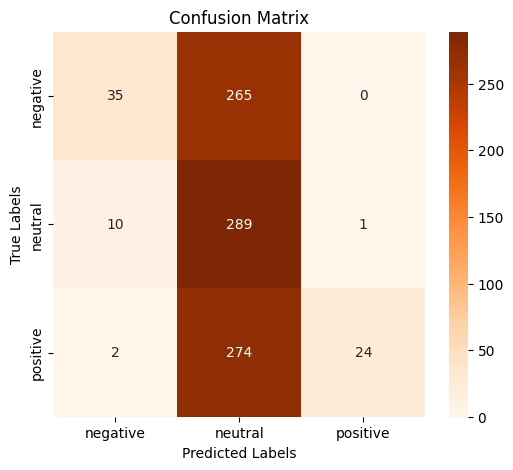

In [12]:
evaluate(y_true, y_pred)

# Conclusions

We fine-tuned **Gemma 4:E2B** model for a sentiment analysis task using Unsloth, PEFT, LoRA in the Notebook [Fine-tune Gemma 4:E2B with Unsloth](https://www.kaggle.com/code/gpreda/fine-tune-gemma-4-e2b-with-unsloth/notebook). In this Notebook we loaded the LoRA weights over the same original (not fine-tuned) model and tested it.